In [1]:
import pandas as pd
import allel
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
clim1001 = pd.read_csv('../key_files/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv')

clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)

In [3]:
meta = pd.read_csv('../key_files/transcptomic_data_meta.csv')

t = pd.read_csv('../key_files/transcriptomics_data_100t.csv')
t = t.drop('Unnamed: 0',axis=1)

In [4]:
cam5_isoforms = [i for i in t.columns if 'AT2G27030' in i]

t = t.set_index('id')



In [5]:
t.index = t.index.astype(str)

In [6]:
cam5_expresion = t[cam5_isoforms]

In [7]:
cam5_expresion = cam5_expresion['AT2G27030.1']

In [8]:
cam5_expresion_dict = cam5_expresion.to_dict()

In [9]:
samples = pd.read_csv('../key_files/merged_sample_table.csv')[['site', 'plot', 'generation', 'total_flower_counts']]

samples = samples.groupby(['site', 'plot', 'generation'])['total_flower_counts'].sum().reset_index()

samples['min_perc'] = 1/samples['total_flower_counts']

samples['code'] = samples['site'].astype(str) + '_'  + samples['generation'].astype(str) + '_' + samples['plot'].astype(str) 

ecotype_freq = pd.read_csv('../key_files/delta_ecotype_freq.txt',sep = '\t')

climate = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')[['site', 'bio1']]

In [10]:
grenenet_ecotypes = pd.read_csv('../key_files/founder_ecotype_frequency.txt', sep = '\t',header=None)[0]

ecotype_freq = ecotype_freq.set_index(grenenet_ecotypes)

ecotype_freq = ecotype_freq.T 
ecotype_freq = ecotype_freq.reset_index()
ecotype_freq['generation'] = ecotype_freq['index'].str.split('_').str[1]

ecotype_freq['plot'] = ecotype_freq['index'].str.split('_').str[2]

ecotype_freq['site'] = ecotype_freq['index'].str.split('_').str[0] 

ecotype_freq = ecotype_freq.drop('index', axis=1)

ecotype_freq = ecotype_freq.melt(id_vars = ['plot','site', 'generation'])

ecotype_freq.columns = ['plot','site', 'generation', 'ecotype', 'freq']

clim1001 = clim1001[['ecotypeid', 'bio1']]

In [11]:
clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(int)

ecotype_freq = ecotype_freq.merge(clim1001, left_on = 'ecotype', right_on = 'ecotypeid')

ecotype_freq['generation'] = ecotype_freq['generation'].astype(int)

result = ecotype_freq.copy()

In [12]:
clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/worldclim_sitesdata.csv')

clim_sites_during_exp = clim_sites_during_exp[['site', 'bio1']]

clim_sites_during_exp['site'] = clim_sites_during_exp['site'].astype(str)

result.columns = ['plot', 'site', 'generation', 'ecotype', 'freq', 'ecotypeid', 'bio1_ecotype']



result = result.merge(clim_sites_during_exp, on ='site')

result.columns = ['plot', 'site', 'generation', 'ecotype', 'freq', 'ecotypeid',
       'bio1_ecotype', 'bio1_exp']



result = result.drop('ecotypeid',axis=1)

In [13]:
cam5_expresion = cam5_expresion.reset_index()

In [14]:
cam5_expresion.columns = ['ecotype', 'expression_isoform3']

In [15]:
cam5_expresion['ecotype'] = cam5_expresion['ecotype'].astype(int)

In [16]:
result = result.merge(cam5_expresion)

In [17]:
import statsmodels.api as sm

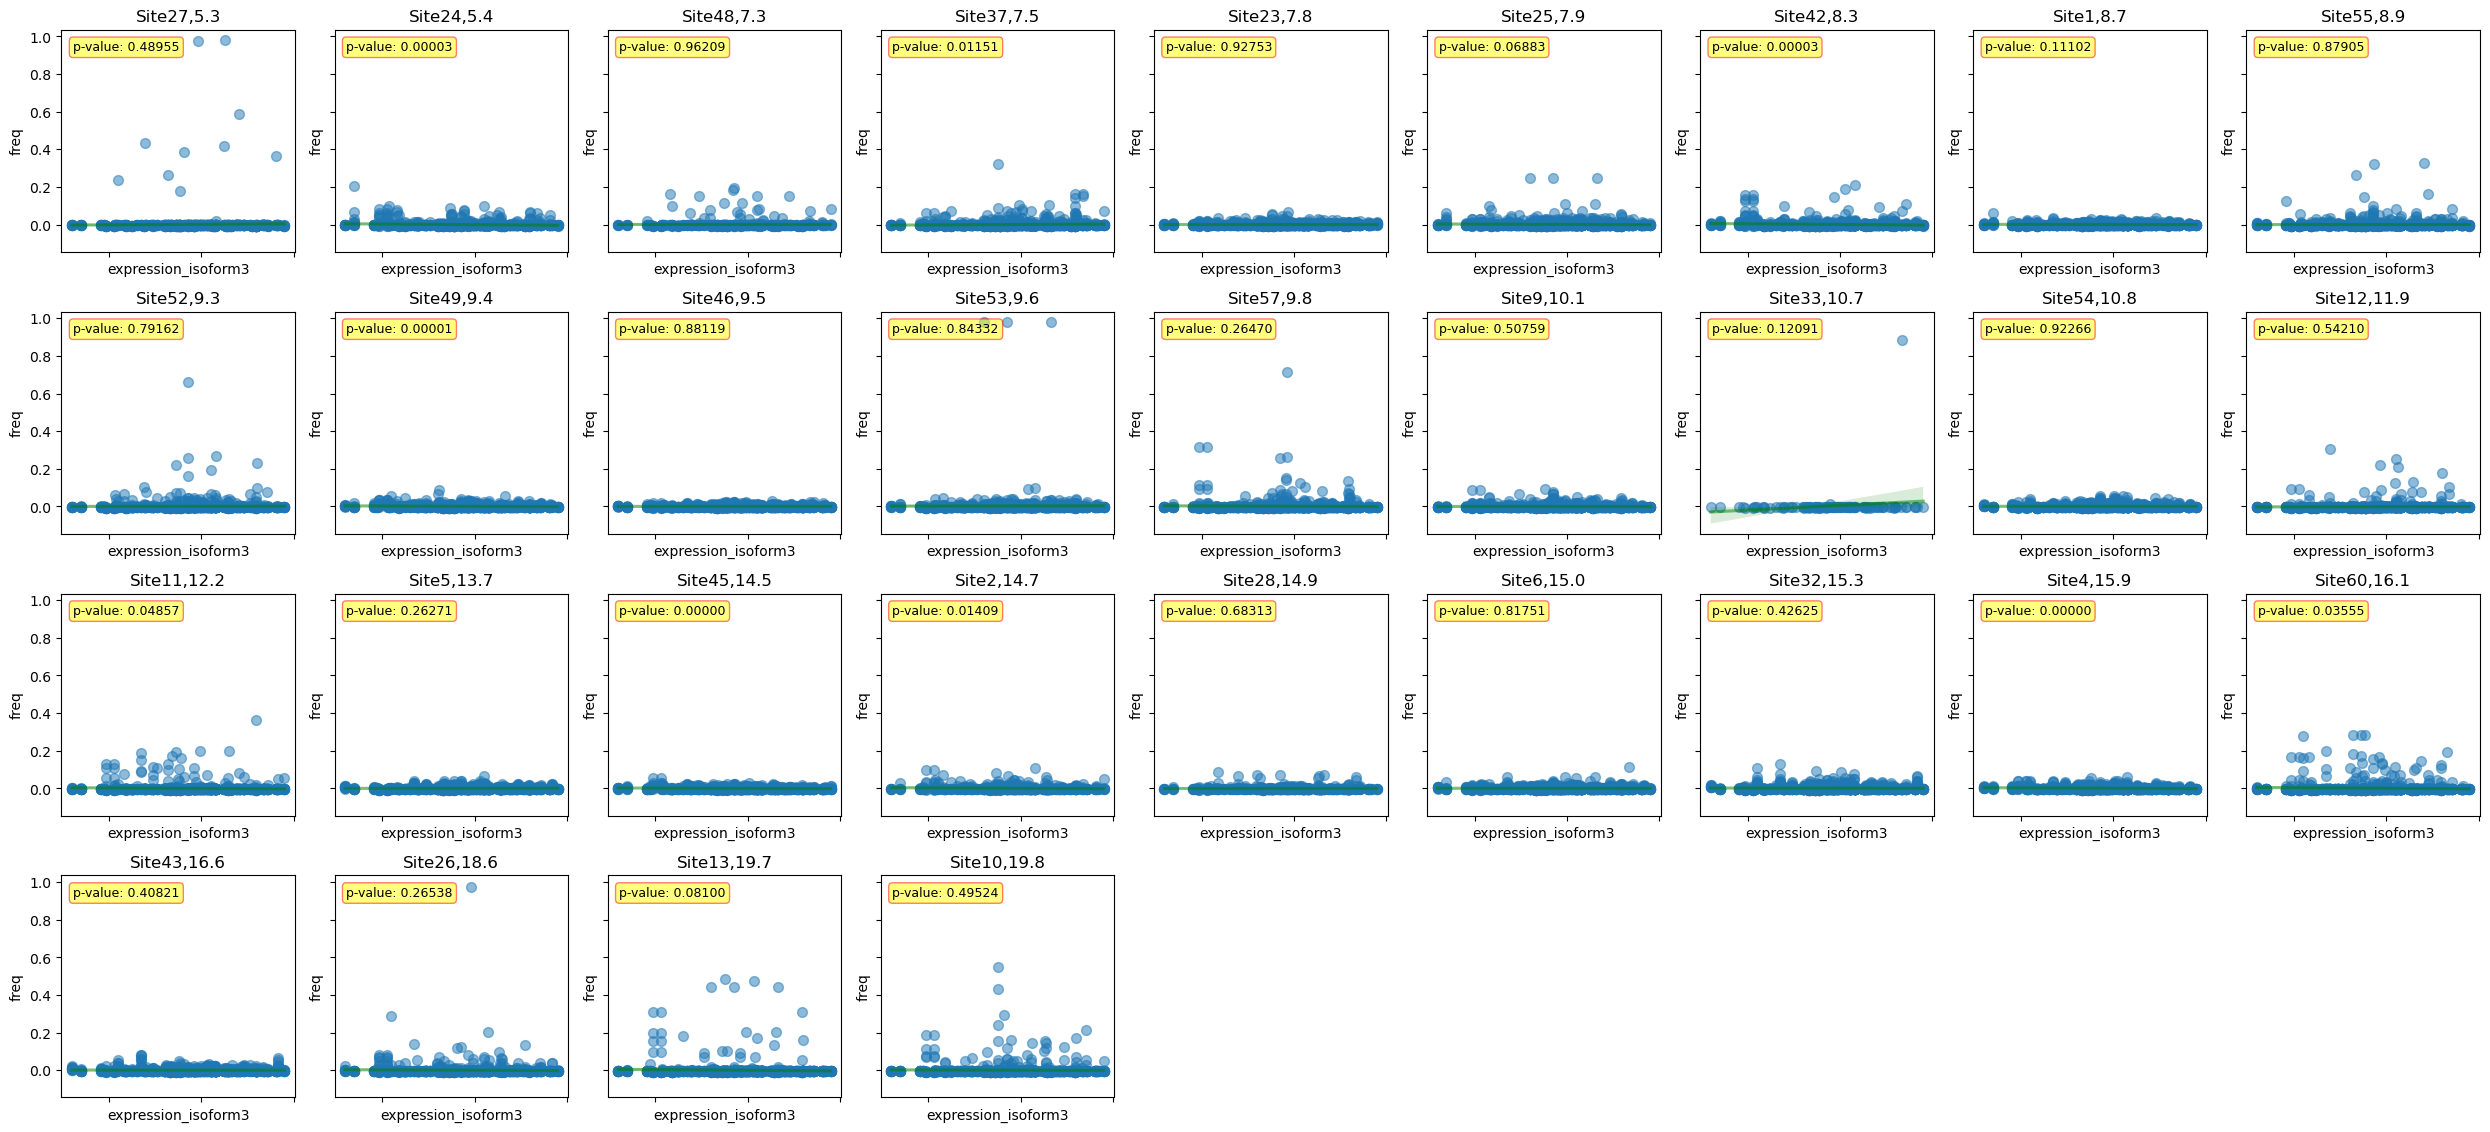

In [19]:
result_w_prsgen3 = result[result['generation']==1]

# Assuming result_w_prsgen3 is your DataFrame
# Step 1: Aggregate bio1_exp for each site (using mean in this example)
site_bio1_exp = result_w_prsgen3.groupby('site')['bio1_exp'].mean()

# Step 2: Sort the sites by bio1_exp
sorted_sites = site_bio1_exp.sort_values().index.tolist()

# Step 3: Determine layout for subplots
num_sites = len(sorted_sites)
num_cols = 3  # Adjust the number of columns as needed
num_rows = (num_sites + num_cols - 1) // num_cols  # Ensures enough rows

# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(25, 14), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes

# Loop through each sorted site and plot
for i, site in enumerate(sorted_sites):
    # Filter data for the current site
    data_filtered = result_w_prsgen3[result_w_prsgen3['site'] == site]

    # Create a scatter plot on the appropriate subplot
    sns.regplot(data=data_filtered, x='expression_isoform3', y='freq', ax=axes[i], 
                scatter_kws={"alpha": 0.5, "s": 50},  # Set alpha to 0.5 for transparency, adjust size 's' as needed
                line_kws={"color": "green","alpha": 0.5})

    # Fit linear regression model
    X = sm.add_constant(data_filtered['expression_isoform3'])  # adding a constant
    model = sm.OLS(data_filtered['freq'], X).fit()
    p_value = model.pvalues[1]  # p-value for the slope

    # Get the bio1_exp value for the title
    bio1_exp_value = site_bio1_exp.loc[site]

    # Set title with site, bio1_exp value, and p-value
    axes[i].set_title(f'Site{site},{bio1_exp_value:.1f}')
    annotation = f'p-value: {p_value:.5f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

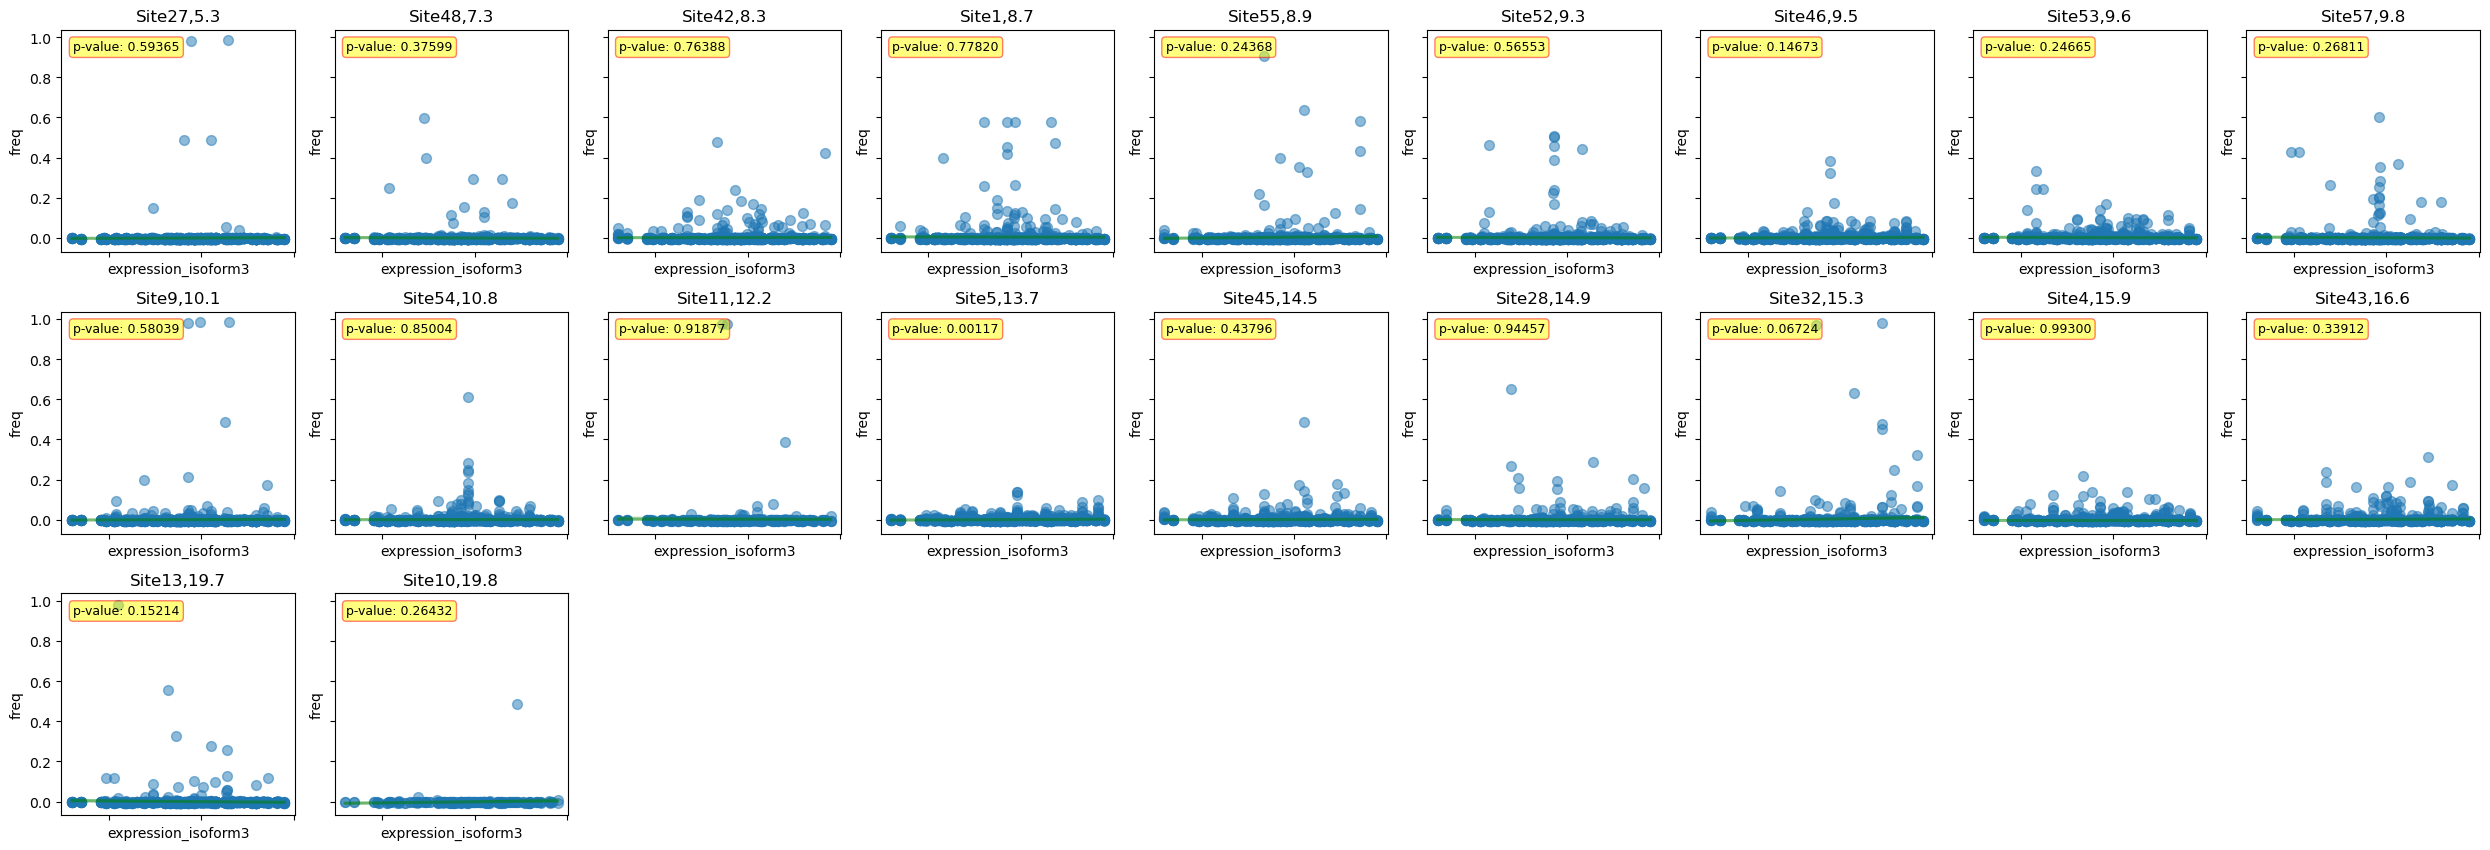

In [20]:
result_w_prsgen3 = result[result['generation']==3]

# Assuming result_w_prsgen3 is your DataFrame
# Step 1: Aggregate bio1_exp for each site (using mean in this example)
site_bio1_exp = result_w_prsgen3.groupby('site')['bio1_exp'].mean()

# Step 2: Sort the sites by bio1_exp
sorted_sites = site_bio1_exp.sort_values().index.tolist()

# Step 3: Determine layout for subplots
num_sites = len(sorted_sites)
num_cols = 3  # Adjust the number of columns as needed
num_rows = (num_sites + num_cols - 1) // num_cols  # Ensures enough rows

# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(25, 14), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the array of axes

# Loop through each sorted site and plot
for i, site in enumerate(sorted_sites):
    # Filter data for the current site
    data_filtered = result_w_prsgen3[result_w_prsgen3['site'] == site]

    # Create a scatter plot on the appropriate subplot
    sns.regplot(data=data_filtered, x='expression_isoform3', y='freq', ax=axes[i], 
                scatter_kws={"alpha": 0.5, "s": 50},  # Set alpha to 0.5 for transparency, adjust size 's' as needed
                line_kws={"color": "green","alpha": 0.5})

    # Fit linear regression model
    X = sm.add_constant(data_filtered['expression_isoform3'])  # adding a constant
    model = sm.OLS(data_filtered['freq'], X).fit()
    p_value = model.pvalues[1]  # p-value for the slope

    # Get the bio1_exp value for the title
    bio1_exp_value = site_bio1_exp.loc[site]

    # Set title with site, bio1_exp value, and p-value
    axes[i].set_title(f'Site{site},{bio1_exp_value:.1f}')
    annotation = f'p-value: {p_value:.5f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and show plot
plt.tight_layout()
plt.show()
